**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD523 Inteligencia Artificial
**GRUPO:** GR1CC  
**FECHA DE ENTREGA LÍMITE:** 04/05/2026   
**ALUMNO:** Renato Aguilar

In [8]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
grafo = {
    'Arad': {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
    'Zerind': {'Arad': 75, 'Oradea': 71},
    'Oradea': {'Zerind': 71, 'Sibiu': 151},
    'Sibiu': {'Arad': 140, 'Oradea': 151, 'Fagaras': 99, 'Rimnicu Vilcea': 80},
    'Timisoara': {'Arad': 118, 'Lugoj': 111},
    'Lugoj': {'Timisoara': 111, 'Mehadia': 70},
    'Mehadia': {'Lugoj': 70, 'Drobeta': 75},
    'Drobeta': {'Mehadia': 75, 'Craiova': 120},
    'Craiova': {'Drobeta': 120, 'Rimnicu Vilcea': 146, 'Pitesti': 138},
    'Rimnicu Vilcea': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
    'Fagaras': {'Sibiu': 99, 'Bucharest': 211},
    'Pitesti': {'Rimnicu Vilcea': 97, 'Craiova': 138, 'Bucharest': 101},
    'Bucharest': {'Fagaras': 211, 'Pitesti': 101, 'Giurgiu': 90, 'Urziceni': 85},
    'Giurgiu': {'Bucharest': 90},
    'Urziceni': {'Bucharest': 85, 'Hirsova': 98, 'Vaslui': 142},
    'Hirsova': {'Urziceni': 98, 'Eforie': 86},
    'Eforie': {'Hirsova': 86},
    'Vaslui': {'Urziceni': 142, 'Iasi': 92},
    'Iasi': {'Vaslui': 92, 'Neamt': 87},
    'Neamt': {'Iasi': 87}
}

heuristica = {
    'Arad': 366,
    'Bucharest': 0,
    'Craiova': 160,
    'Drobeta': 242,
    'Eforie': 161,
    'Fagaras': 176,
    'Giurgiu': 77,
    'Hirsova': 151,
    'Iasi': 226,
    'Lugoj': 244,
    'Mehadia': 241,
    'Neamt': 234,
    'Oradea': 380,
    'Pitesti': 100,
    'Rimnicu Vilcea': 193,
    'Sibiu': 253,
    'Timisoara': 329,
    'Urziceni': 80,
    'Vaslui': 199,
    'Zerind': 374
}

## GBFS

In [40]:
def gbfs(grafo, heuristica, nodo_inicial, objetivo):
    frontera = []
    visitados = set()

    # En GBFS la prioridad es f(n) = h(n)
    heapq.heappush(frontera, (heuristica[nodo_inicial], nodo_inicial, [nodo_inicial], 0))

    secuencia_considerada = []

    print("=====================================")
    print("BÚSQUEDA GBFS")
    print("=====================================")
    print(f"Nodo inicial: {nodo_inicial}")
    print(f"Objetivo: {objetivo}")
    print()

    while frontera:
        print("Frontera actual:")
        for h, nodo, camino, costo in sorted(frontera):
            print(f"  Nodo: {nodo:15} f(n)=h(n)={h}")

        print()

        h_actual, nodo_actual, camino_actual, costo_actual = heapq.heappop(frontera)

        print(f"Se selecciona el nodo con menor heurística:")
        print(f"  Nodo actual: {nodo_actual}")
        print(f"  f({nodo_actual}) = h({nodo_actual}) = {h_actual}")
        print("-------------------------------------")

        secuencia_considerada.append((nodo_actual, h_actual))

        if nodo_actual == objetivo:
            return camino_actual, costo_actual, secuencia_considerada

        if nodo_actual not in visitados:
            visitados.add(nodo_actual)

            for vecino, costo in grafo[nodo_actual].items():
                if vecino not in visitados:
                    nuevo_camino = camino_actual + [vecino]
                    nuevo_costo = costo_actual + costo
                    heapq.heappush(
                        frontera,
                        (heuristica[vecino], vecino, nuevo_camino, nuevo_costo)
                    )

    return None, None, secuencia_considerada

def mostrar_solucion(camino, costo_total, secuencia, algoritmo):
    print()
    print("=====================================")
    print("RESULTADO FINAL")
    print("=====================================")
    if algoritmo == 'GBFS':
        print("Secuencia de nodos considerados por GBFS:")
        for nodo, h in secuencia:
            print(f"  {nodo:15} f(n)=h(n)={h}")
        
        print()
        
        if camino:
            print("Camino encontrado:")
            print(" -> ".join(camino))
        
            print()
            print(f"Costo total del camino: {costo_total}")
        else:
            print("No se encontró un camino.")
    else:
        print("Secuencia de nodos considerados por A*:")
        for nodo, g, h, f in secuencia:
            print(f"  {nodo:15} g(n)={g:3}  h(n)={h:3}  f(n)={f:3}")
        
        print()
        
        if camino:
            print("Camino encontrado:")
            print(" -> ".join(camino))
        
            print()
            print(f"Costo total del camino g(n): {costo_total}")
        else:
            print("No se encontró un camino.")


inicio = 'Lugoj'
objetivo = 'Bucharest'

camino, costo_total, secuencia = gbfs(grafo, heuristica, inicio, objetivo)

mostrar_solucion(camino, costo_total, secuencia, 'GBFS')

BÚSQUEDA GBFS
Nodo inicial: Lugoj
Objetivo: Bucharest

Frontera actual:
  Nodo: Lugoj           f(n)=h(n)=244

Se selecciona el nodo con menor heurística:
  Nodo actual: Lugoj
  f(Lugoj) = h(Lugoj) = 244
-------------------------------------
Frontera actual:
  Nodo: Mehadia         f(n)=h(n)=241
  Nodo: Timisoara       f(n)=h(n)=329

Se selecciona el nodo con menor heurística:
  Nodo actual: Mehadia
  f(Mehadia) = h(Mehadia) = 241
-------------------------------------
Frontera actual:
  Nodo: Drobeta         f(n)=h(n)=242
  Nodo: Timisoara       f(n)=h(n)=329

Se selecciona el nodo con menor heurística:
  Nodo actual: Drobeta
  f(Drobeta) = h(Drobeta) = 242
-------------------------------------
Frontera actual:
  Nodo: Craiova         f(n)=h(n)=160
  Nodo: Timisoara       f(n)=h(n)=329

Se selecciona el nodo con menor heurística:
  Nodo actual: Craiova
  f(Craiova) = h(Craiova) = 160
-------------------------------------
Frontera actual:
  Nodo: Pitesti         f(n)=h(n)=100
  Nodo: Ri

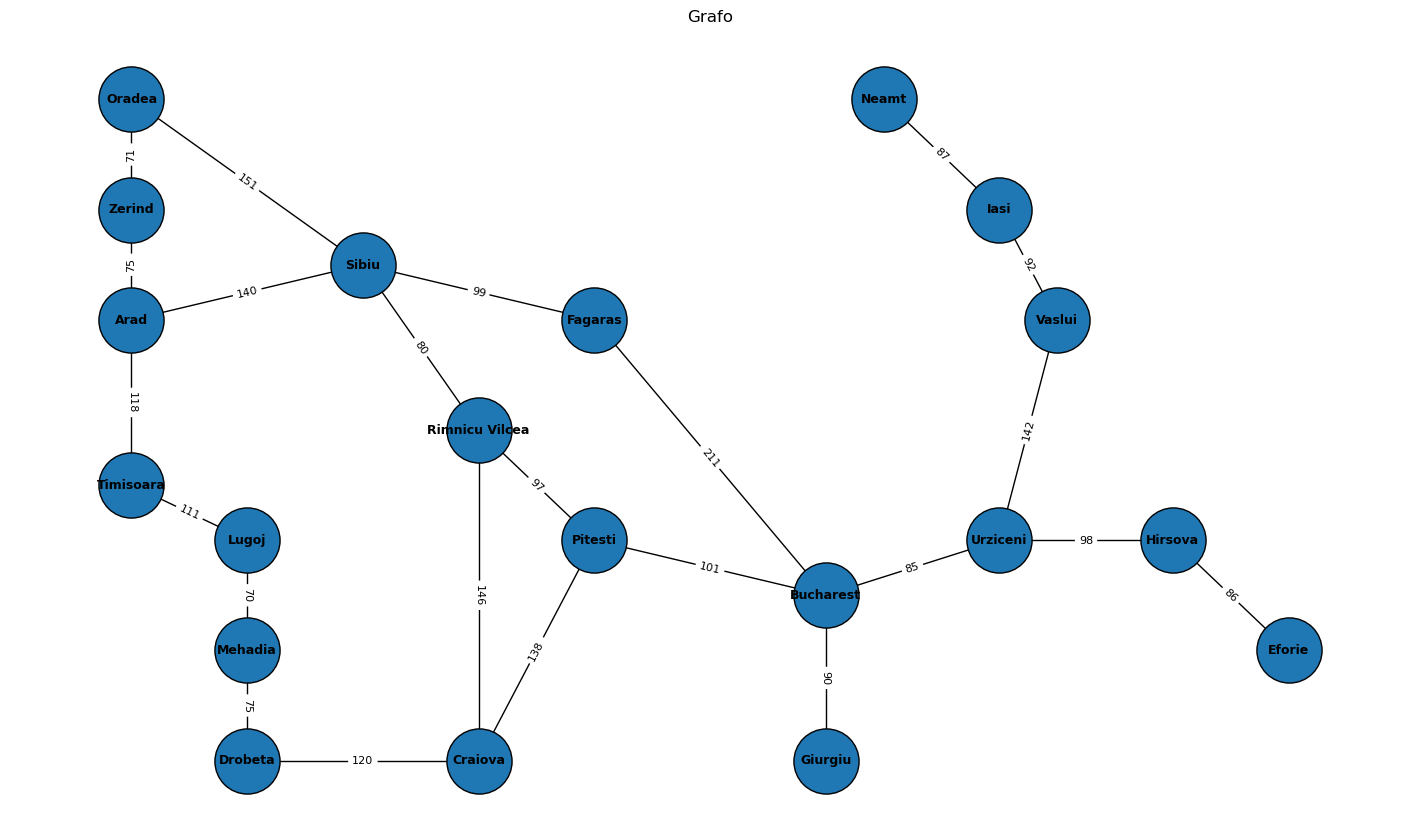

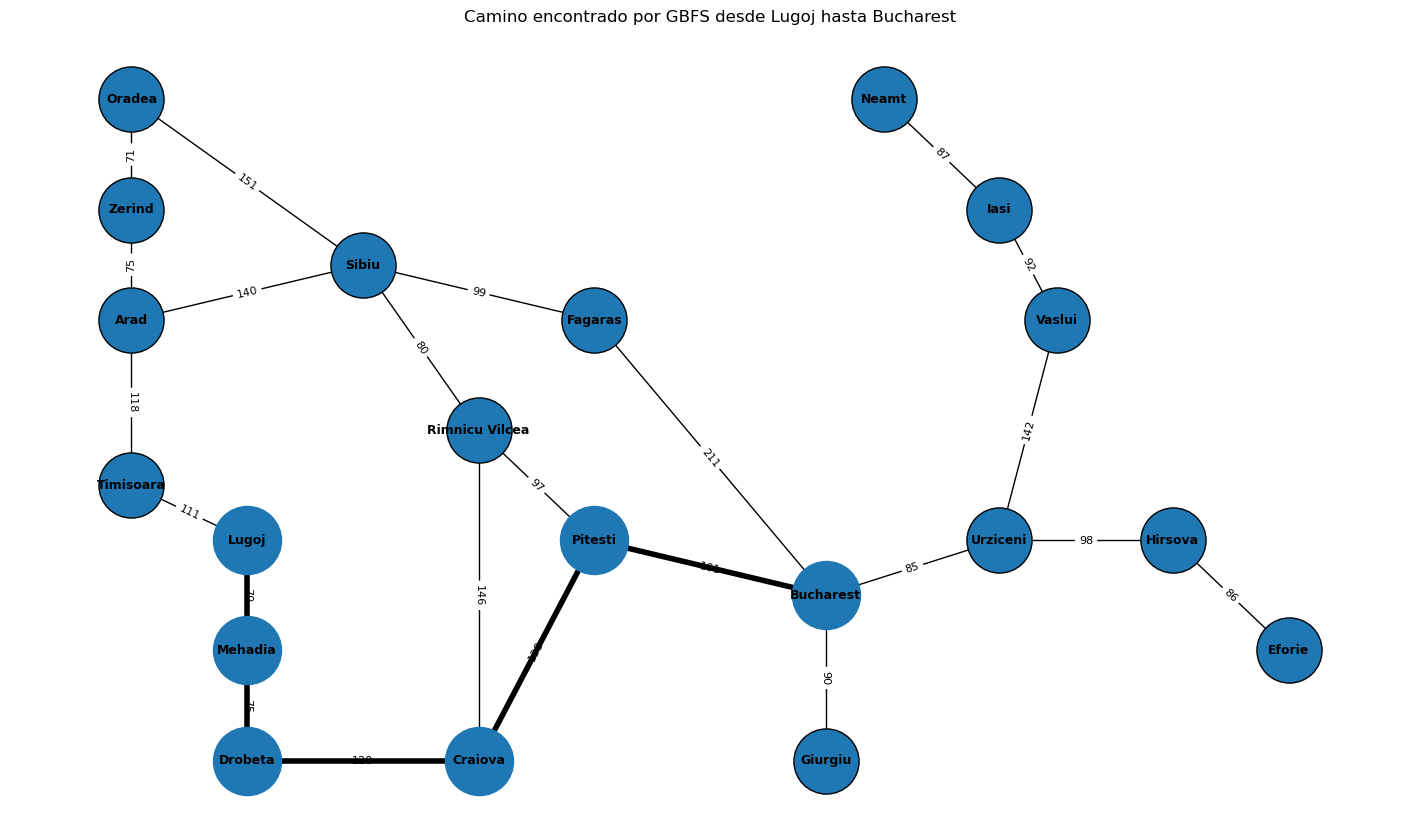

In [41]:
def dibujar_mapa(grafo):
    G = nx.Graph()
    # Agregar nodos y aristas
    for ciudad, vecinos in grafo.items():
        for vecino, costo in vecinos.items():
            G.add_edge(ciudad, vecino, weight=costo)
    
    # Posiciones aproximadas para que se vea parecido al mapa de Rumania
    pos = {
        'Oradea': (1, 6),
        'Zerind': (1, 5),
        'Arad': (1, 4),
        'Timisoara': (1, 2.5),
        'Lugoj': (2, 2),
        'Mehadia': (2, 1),
        'Drobeta': (2, 0),
        'Craiova': (4, 0),
        'Rimnicu Vilcea': (4, 3),
        'Sibiu': (3, 4.5),
        'Fagaras': (5, 4),
        'Pitesti': (5, 2),
        'Bucharest': (7, 1.5),
        'Giurgiu': (7, 0),
        'Urziceni': (8.5, 2),
        'Hirsova': (10, 2),
        'Eforie': (11, 1),
        'Vaslui': (9, 4),
        'Iasi': (8.5, 5),
        'Neamt': (7.5, 6)
    }
    
    plt.figure(figsize=(14, 8))
    
    # Dibujar nodos y aristas
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2200,
        font_size=9,
        font_weight='bold',
        edgecolors='black'
    )
    
    # Dibujar pesos de las aristas
    etiquetas_aristas = nx.get_edge_attributes(G, 'weight')
    
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=etiquetas_aristas,
        font_size=8
    )
    
    plt.title("Grafo")
    plt.axis('off')
    plt.show()
    return G, pos

G, pos = dibujar_mapa(grafo)
# DIBUJAR EL CAMINO ENCONTRADO POR GBFS
def dibujar_solucion(G, pos, camino, algoritmo):
    plt.figure(figsize=(14, 8))
    
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2200,
        font_size=9,
        font_weight='bold',
        edgecolors='black'
    )
    etiquetas_aristas = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=etiquetas_aristas,
        font_size=8
    )
    
    # Convertir el camino en pares de aristas
    aristas_camino = list(zip(camino, camino[1:]))
    
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=aristas_camino,
        width=4
    )
    
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=camino,
        node_size=2400
    )
    if algoritmo == 'GBFS':
        plt.title("Camino encontrado por GBFS desde Lugoj hasta Bucharest")
        plt.axis('off')
        plt.show()
    else:
        plt.title("Camino encontrado por A* desde Lugoj hasta Bucharest")
        plt.axis('off')
        plt.show()

dibujar_solucion(G, pos, camino, 'GBFS')

## A*

In [36]:
def a_estrella(grafo, heuristica, nodo_inicial, objetivo):
    frontera = []
    visitados = set()
    secuencia_considerada = []

    # g(nodo_inicial) = 0
    g_inicial = 0
    h_inicial = heuristica[nodo_inicial]
    f_inicial = g_inicial + h_inicial

    # En A*: prioridad = f(n) = g(n) + h(n)
    heapq.heappush(
        frontera,
        (f_inicial, g_inicial, nodo_inicial, [nodo_inicial])
    )

    print("=====================================")
    print("BÚSQUEDA A*")
    print("=====================================")
    print(f"Nodo inicial: {nodo_inicial}")
    print(f"Objetivo: {objetivo}")
    print()

    while frontera:
        print("Frontera actual:")
        for f, g, nodo, camino in sorted(frontera):
            h = heuristica[nodo]
            print(f"  Nodo: {nodo:15} g(n)={g:3}  h(n)={h:3}  f(n)={f:3}")

        print()

        f_actual, g_actual, nodo_actual, camino_actual = heapq.heappop(frontera)
        h_actual = heuristica[nodo_actual]

        print("Se selecciona el nodo con menor f(n):")
        print(f"  Nodo actual: {nodo_actual}")
        print(f"  g({nodo_actual}) = {g_actual}")
        print(f"  h({nodo_actual}) = {h_actual}")
        print(f"  f({nodo_actual}) = g({nodo_actual}) + h({nodo_actual}) = {f_actual}")
        print("-------------------------------------")

        secuencia_considerada.append((nodo_actual, g_actual, h_actual, f_actual))

        if nodo_actual == objetivo:
            return camino_actual, g_actual, secuencia_considerada

        if nodo_actual not in visitados:
            visitados.add(nodo_actual)

            for vecino, costo in grafo[nodo_actual].items():
                if vecino not in visitados:
                    nuevo_g = g_actual + costo
                    nuevo_h = heuristica[vecino]
                    nuevo_f = nuevo_g + nuevo_h
                    nuevo_camino = camino_actual + [vecino]

                    heapq.heappush(
                        frontera,
                        (nuevo_f, nuevo_g, vecino, nuevo_camino)
                    )

    return None, None, secuencia_considerada

inicio = 'Lugoj'
objetivo = 'Bucharest'

camino, costo_total, secuencia = a_estrella(grafo, heuristica, inicio, objetivo)

mostrar_solucion(camino, costo_total, secuencia, 'A*')

BÚSQUEDA A*
Nodo inicial: Lugoj
Objetivo: Bucharest

Frontera actual:
  Nodo: Lugoj           g(n)=  0  h(n)=244  f(n)=244

Se selecciona el nodo con menor f(n):
  Nodo actual: Lugoj
  g(Lugoj) = 0
  h(Lugoj) = 244
  f(Lugoj) = g(Lugoj) + h(Lugoj) = 244
-------------------------------------
Frontera actual:
  Nodo: Mehadia         g(n)= 70  h(n)=241  f(n)=311
  Nodo: Timisoara       g(n)=111  h(n)=329  f(n)=440

Se selecciona el nodo con menor f(n):
  Nodo actual: Mehadia
  g(Mehadia) = 70
  h(Mehadia) = 241
  f(Mehadia) = g(Mehadia) + h(Mehadia) = 311
-------------------------------------
Frontera actual:
  Nodo: Drobeta         g(n)=145  h(n)=242  f(n)=387
  Nodo: Timisoara       g(n)=111  h(n)=329  f(n)=440

Se selecciona el nodo con menor f(n):
  Nodo actual: Drobeta
  g(Drobeta) = 145
  h(Drobeta) = 242
  f(Drobeta) = g(Drobeta) + h(Drobeta) = 387
-------------------------------------
Frontera actual:
  Nodo: Craiova         g(n)=265  h(n)=160  f(n)=425
  Nodo: Timisoara       g(n

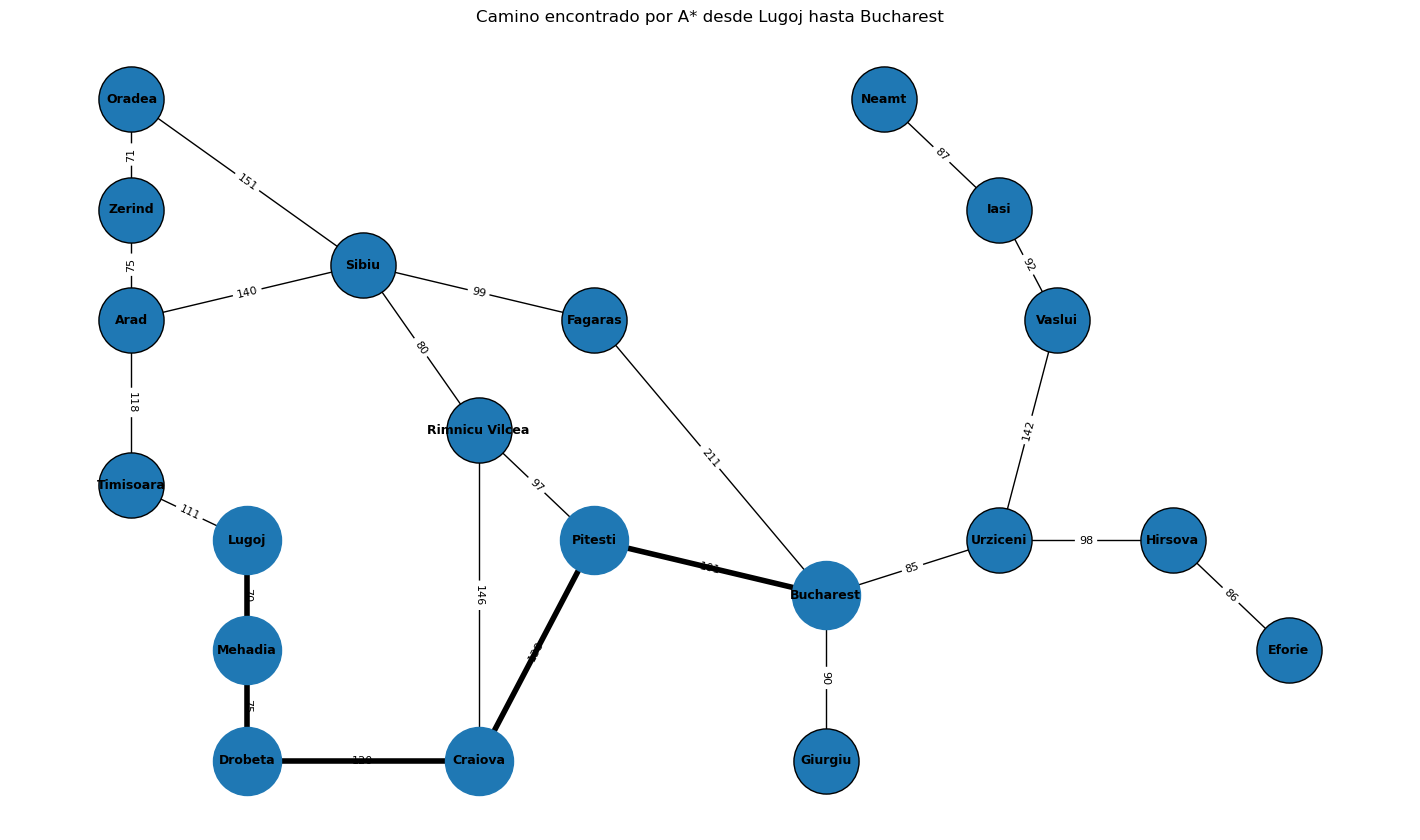

In [37]:
dibujar_solucion(G, pos, camino, 'A*')